<a href="https://colab.research.google.com/github/RubaEgbaria/Esch-Crowd-Monitoring/blob/master/lab_experiment_pedestrian_camera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Camera-only Experiment Counting Analysis


## Experiment Setup

This notebook documents a pedestrian detection experiment conducted at the University of Luxembourg's Advanced Engineering and Smart Sensors Solutions (AE3S) lab. The experiment was designed to evaluate pedestrian counting accuracy in a controlled setting that simulates real-world crowd monitoring scenarios. A camera was mounted at a height of 245 cm overlooking the monitored area, capturing continuous video footage of pedestrian movement. The raw video was preprocessed using the vid_rectangle_cleaner.ipynb notebook to remove artifacts and clean the frames for analysis.

The experiment compares three detection approaches: (1) a camera application deployed using the people_counter_from_vid.ipynb notebook, (2) a pretrained YOLOv8m model for pedestrian detection, and (3) manually annotated ground truth data. The ground truth was established by carefully reviewing the video at each second and recording the actual number of pedestrians present in the scene, providing a reliable baseline for evaluating both the camera app and the YOLO model. This three-way comparison allows us to assess the performance characteristics of each method in the same experimental conditions, revealing their strengths and limitations for practical crowd monitoring applications.

In [3]:
!pip install ultralytics -q

In [4]:
import cv2
import numpy as np
from ultralytics import YOLO

video_path = "raw-vid.mp4"
model = YOLO('yolo11m.pt')

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
T = total_frames / fps

print(f"Video: {fps:.1f} fps, {total_frames} frames, {T:.1f}s duration")


Video: 10.5 fps, 454 frames, 43.2s duration


## 1) YOLO

In [5]:
def detect_pedestrians(frame, confidence_threshold=0.2):
    results = model(frame, verbose=False)
    annotations = []

    if not results:
        return annotations

    result = results[0]
    for box in result.boxes:
        if float(box.conf) < confidence_threshold:
            continue
        if result.names[int(box.cls)] != "person":
            continue

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        annotations.append({
            "x": round(cx),
            "y": round(cy),
            "label": "person",
            "confidence": round(float(box.conf), 2),
            "box": [round(x1), round(y1), round(x2), round(y2)],
        })

    return annotations


predictions = {}
cap = cv2.VideoCapture(video_path)
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    detections = detect_pedestrians(frame_rgb)
    timestamp = frame_idx / fps

    predictions[f"frame_{frame_idx:06d}"] = {
        "timestamp": round(timestamp, 2),
        "detections": detections,
        "count": len(detections)
    }

    if frame_idx % 30 == 0:
        print(f"Frame {frame_idx}/{total_frames}: {len(detections)} people detected")

    frame_idx += 1

cap.release()
print(f"\nProcessed {frame_idx} frames")


Frame 0/454: 0 people detected
Frame 30/454: 5 people detected
Frame 60/454: 5 people detected
Frame 90/454: 6 people detected
Frame 120/454: 6 people detected
Frame 150/454: 6 people detected
Frame 180/454: 6 people detected
Frame 210/454: 4 people detected
Frame 240/454: 5 people detected
Frame 270/454: 5 people detected
Frame 300/454: 6 people detected
Frame 330/454: 5 people detected
Frame 360/454: 6 people detected
Frame 390/454: 6 people detected
Frame 420/454: 4 people detected
Frame 450/454: 6 people detected

Processed 454 frames


## 2) Ground truth from YOLO-format label files (top-view frames)


In [7]:
VIDEO_CONFIGS = {
    "baseline": {
        "description": "Standard video - crowded middle section",
        "segments": [
            (0, 4.0, 5),
            (4.0, "T-4.0", 6),
            ("T-4.0", "T", 5),
        ]
    },
    "less_crowded": {
        "description": "Consistently sparse",
        "segments": [(0, "T", 5)]
    },
    "lights_off": {
        "description": "Low lighting conditions",
        "segments": [
            (0, 6.0, 5),
            (6.0, "T-3.0", 6),
            ("T-3.0", "T", 5),
        ]
    },
    "with_items": {
        "description": "People carrying items",
        "segments": [
            (0, 5.0, 4),
            (5.0, "T-3.0", 6),
            ("T-3.0", "T", 5),
        ]
    },
}

def resolve_segments(video_type, T_duration):
    if video_type not in VIDEO_CONFIGS:
        raise ValueError(f"Unknown video_type: {video_type}")

    raw = VIDEO_CONFIGS[video_type]["segments"]
    resolved = []

    for start, end, num_people in raw:
        if isinstance(start, str):
            start = T_duration if start == "T" else T_duration - float(start.split("-")[1])
        if isinstance(end, str):
            end = T_duration if end == "T" else T_duration - float(end.split("-")[1])
        resolved.append((start, end, num_people))

    return resolved

VIDEO_TYPE = "baseline"
# T is already defined as video duration from cell zMMzDK8Qyjl4
gt_segments = resolve_segments(VIDEO_TYPE, T)

ground_truth = {}

for frame_key, pred_data in predictions.items():
    timestamp = pred_data["timestamp"]
    num_people = 0

    for start, end, count in gt_segments:
        if start <= timestamp < end:
            num_people = count
            break

    ground_truth[frame_key] = {
        "timestamp": timestamp,
        "expected_count": num_people
    }

print(f"Generated ground truth for {len(ground_truth)} frames")

Generated ground truth for 454 frames


In [9]:
import json

with open('detection_counts.json', 'r') as f:
    camera_data = json.load(f)

camera_predictions = {}
second_idx = 0

for frame_idx, count in camera_data['per_frame'].items():
    frame_key = f"frame_{int(frame_idx):06d}"
    timestamp = int(frame_idx) / fps

    camera_predictions[frame_key] = {
        "timestamp": round(timestamp, 2),
        "count": count
    }
    second_idx += 1

print(f"Loaded camera app detections for {len(camera_predictions)} frames")


Loaded camera app detections for 454 frames


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_data = []

for frame_key in sorted(predictions.keys()):
    pred_count = predictions[frame_key]["count"]
    gt_count = ground_truth[frame_key]["expected_count"]
    camera_count = camera_predictions[frame_key]["count"]
    timestamp = predictions[frame_key]["timestamp"]

    comparison_data.append({
        "timestamp": timestamp,
        "ground_truth": gt_count,
        "camera_app": camera_count,
        "yolo_model": pred_count,
        "error_camera": abs(camera_count - gt_count),
        "error_yolo": abs(pred_count - gt_count)
    })

df_comparison = pd.DataFrame(comparison_data)

print("\n=== COMPARISON: Ground Truth vs Camera App vs YOLO ===")
print(f"{'Time':>8} {'GT':>4} {'Camera':>7} {'YOLO':>6} {'Cam Err':>8} {'YOLO Err':>9}")
for idx, row in df_comparison.head(30).iterrows():
    print(f"{row['timestamp']:>8.2f} {row['ground_truth']:>4.0f} {row['camera_app']:>7.0f} "
          f"{row['yolo_model']:>6.0f} {row['error_camera']:>8.0f} {row['error_yolo']:>9.0f}")

print(f"\n{'Metric':>20} {'Ground Truth':>15} {'Camera App':>12} {'YOLO':>10}")
print("-" * 60)
print(f"{'Mean Count':>20} {df_comparison['ground_truth'].mean():>15.2f} "
      f"{df_comparison['camera_app'].mean():>12.2f} {df_comparison['yolo_model'].mean():>10.2f}")
print(f"{'Std Dev':>20} {df_comparison['ground_truth'].std():>15.2f} "
      f"{df_comparison['camera_app'].std():>12.2f} {df_comparison['yolo_model'].std():>10.2f}")

camera_mae = df_comparison['error_camera'].mean()
yolo_mae = df_comparison['error_yolo'].mean()

print(f"\n{'Mean Absolute Error':>20} {'':>15} {camera_mae:>12.2f} {yolo_mae:>10.2f}")
print(f"{'Median Absolute Error':>20} {'':>15} "
      f"{df_comparison['error_camera'].median():>12.2f} {df_comparison['error_yolo'].median():>10.2f}")



=== COMPARISON: Ground Truth vs Camera App vs YOLO ===
    Time   GT  Camera   YOLO  Cam Err  YOLO Err
    0.00    5       0      0        5         5
    0.10    5       1      5        4         0
    0.19    5       1      5        4         0
    0.29    5       1      5        4         0
    0.38    5       0      4        5         1
    0.48    5       0      5        5         0
    0.57    5       0      5        5         0
    0.67    5       1      5        4         0
    0.76    5       0      5        5         0
    0.86    5       1      6        4         1
    0.95    5       0      5        5         0
    1.05    5       0      5        5         0
    1.14    5       2      5        3         0
    1.24    5       2      5        3         0
    1.33    5       1      5        4         0
    1.43    5       1      5        4         0
    1.52    5       1      5        4         0
    1.62    5       4      5        1         0
    1.71    5       0      5    

## 3) Ground Truth (Matching)

In [11]:
per_frame_results = []
total_error = 0

for frame_key in sorted(predictions.keys()):
    pred_count = predictions[frame_key]["count"]
    gt_count = ground_truth[frame_key]["expected_count"]
    timestamp = predictions[frame_key]["timestamp"]
    error = abs(pred_count - gt_count)
    total_error += error

    per_frame_results.append({
        "frame": frame_key,
        "timestamp": timestamp,
        "predicted": pred_count,
        "expected": gt_count,
        "error": error
    })

print(f"{'Frame':>15} {'Time':>8} {'Pred':>5} {'Expected':>8} {'Error':>6}")
for r in per_frame_results[:20]:
    print(f"{r['frame']:>15} {r['timestamp']:>8.2f} {r['predicted']:>5} {r['expected']:>8} {r['error']:>6}")

if len(per_frame_results) > 20:
    print(f"... and {len(per_frame_results) - 20} more frames")

mean_error = total_error / len(per_frame_results) if per_frame_results else 0
print(f"\nMean Absolute Error: {mean_error:.2f} people")


          Frame     Time  Pred Expected  Error
   frame_000000     0.00     0        5      5
   frame_000001     0.10     5        5      0
   frame_000002     0.19     5        5      0
   frame_000003     0.29     5        5      0
   frame_000004     0.38     4        5      1
   frame_000005     0.48     5        5      0
   frame_000006     0.57     5        5      0
   frame_000007     0.67     5        5      0
   frame_000008     0.76     5        5      0
   frame_000009     0.86     6        5      1
   frame_000010     0.95     5        5      0
   frame_000011     1.05     5        5      0
   frame_000012     1.14     5        5      0
   frame_000013     1.24     5        5      0
   frame_000014     1.33     5        5      0
   frame_000015     1.43     5        5      0
   frame_000016     1.52     5        5      0
   frame_000017     1.62     5        5      0
   frame_000018     1.71     5        5      0
   frame_000019     1.81     5        5      0
... and 434 m

In [13]:
per_frame_results = []
total_tp, total_fp, total_fn = 0, 0, 0

for fname in sorted(ground_truth.keys()):
    # Get predicted count
    pred_data = predictions.get(fname, {})
    predicted_count = pred_data.get("count", 0) # Default to 0 if frame not in predictions

    # Get ground truth count
    gt_data = ground_truth.get(fname, {})
    ground_truth_count = gt_data.get("expected_count", 0) # Default to 0 if frame not in ground_truth

    # Calculate TP, FP, FN based on counts
    tp_n = min(predicted_count, ground_truth_count)
    fp_n = max(0, predicted_count - ground_truth_count)
    fn_n = max(0, ground_truth_count - predicted_count)

    total_tp += tp_n
    total_fp += fp_n
    total_fn += fn_n

    precision = tp_n / (tp_n + fp_n) if (tp_n + fp_n) else 0
    recall = tp_n / (tp_n + fn_n) if (tp_n + fn_n) else 0
    per_frame_results.append({"frame": fname, "tp": tp_n, "fp": fp_n, "fn": fn_n,
                               "precision": round(precision, 2), "recall": round(recall, 2)})

print(f"{'frame':>20} {'TP':>4} {'FP':>4} {'FN':>4} {'prec':>6} {'recall':>7}")
for r in per_frame_results:
    print(f"{r['frame']:>20} {r['tp']:>4} {r['fp']:>4} {r['fn']:>4} {r['precision']:>6} {r['recall']:>7}")

overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0
overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0
overall_f1 = (2 * overall_precision * overall_recall / (overall_precision + overall_recall)
              if (overall_precision + overall_recall) else 0)

print(f"\n=== OVERALL (camera-only, {len(ground_truth)} frames) ===")
print(f"TP={total_tp}  FP={total_fp}  FN={total_fn}")
print(f"Precision={overall_precision:.2f}  Recall={overall_recall:.2f}  F1={overall_f1:.2f}")

               frame   TP   FP   FN   prec  recall
        frame_000000    0    0    5      0     0.0
        frame_000001    5    0    0    1.0     1.0
        frame_000002    5    0    0    1.0     1.0
        frame_000003    5    0    0    1.0     1.0
        frame_000004    4    0    1    1.0     0.8
        frame_000005    5    0    0    1.0     1.0
        frame_000006    5    0    0    1.0     1.0
        frame_000007    5    0    0    1.0     1.0
        frame_000008    5    0    0    1.0     1.0
        frame_000009    5    1    0   0.83     1.0
        frame_000010    5    0    0    1.0     1.0
        frame_000011    5    0    0    1.0     1.0
        frame_000012    5    0    0    1.0     1.0
        frame_000013    5    0    0    1.0     1.0
        frame_000014    5    0    0    1.0     1.0
        frame_000015    5    0    0    1.0     1.0
        frame_000016    5    0    0    1.0     1.0
        frame_000017    5    0    0    1.0     1.0
        frame_000018    5    0 

## 4) Confusion Matrix

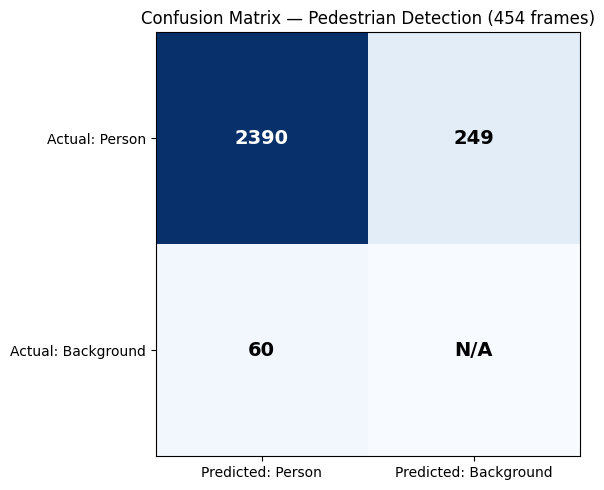

Accuracy (TP / (TP+FP+FN)) = 88.55%
Precision = 97.55%
Recall    = 90.56%
F1 Score  = 93.93%


In [14]:
import numpy as np

cm = np.array([[total_tp, total_fn],
               [total_fp, 0]])

labels = ["Detected", "Missed (FN)"]
row_labels = ["Actual: Person", "Actual: Background"]
col_labels = ["Predicted: Person", "Predicted: Background"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1]); ax.set_xticklabels(col_labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(row_labels)

for i in range(2):
    for j in range(2):
        val = cm[i, j]
        txt = str(val) if not (i == 1 and j == 1) else "N/A"
        ax.text(j, i, txt, ha="center", va="center",
                color="white" if val > cm.max() / 2 else "black", fontsize=14, weight="bold")

ax.set_title(f"Confusion Matrix — Pedestrian Detection ({len(ground_truth)} frames)")
plt.tight_layout()
plt.show()

print(f"Accuracy (TP / (TP+FP+FN)) = {total_tp / (total_tp + total_fp + total_fn):.2%}")
print(f"Precision = {overall_precision:.2%}")
print(f"Recall    = {overall_recall:.2%}")
print(f"F1 Score  = {overall_f1:.2%}")


## 5) More visulaizations

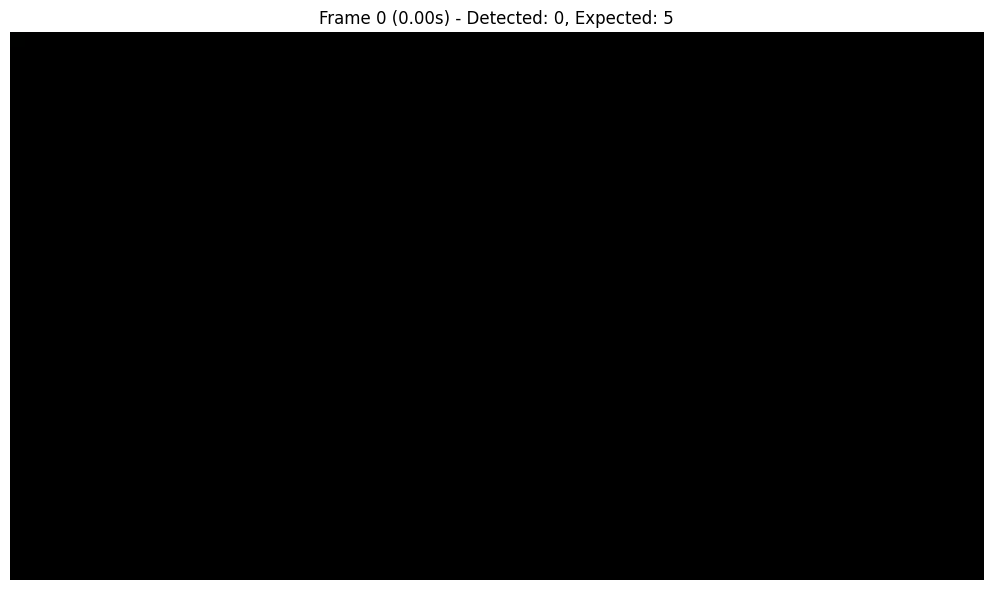

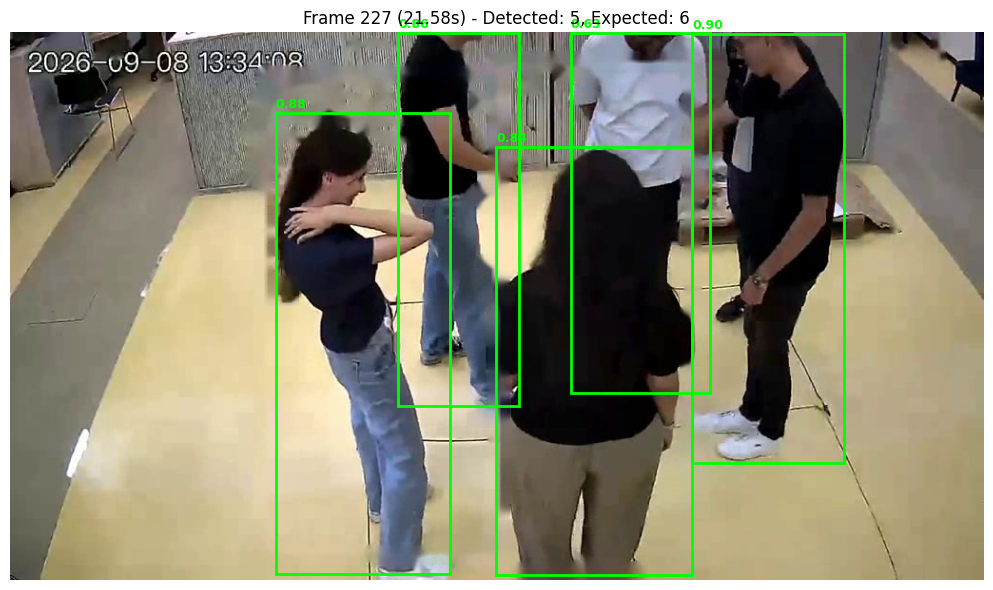

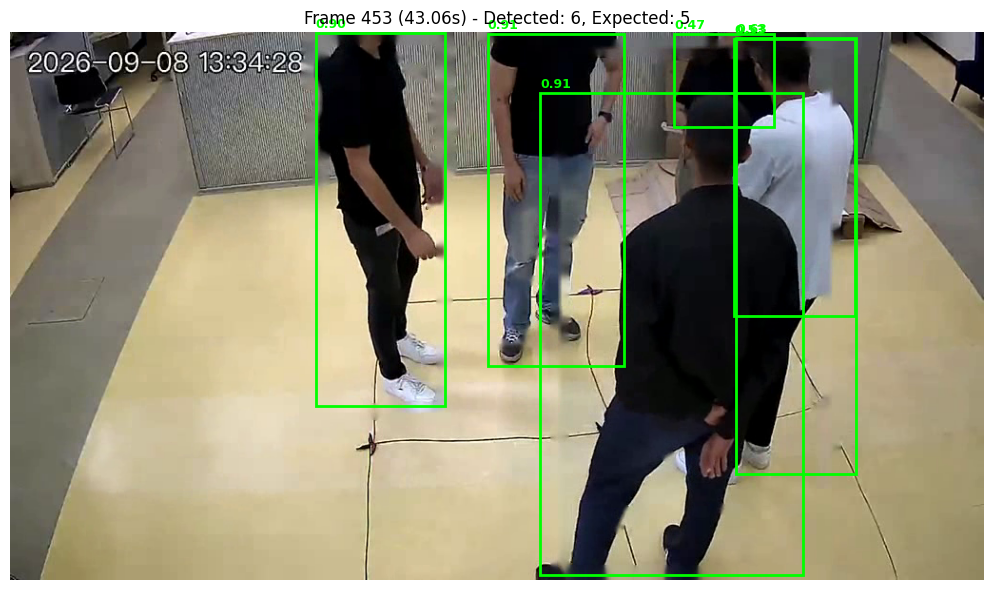

In [15]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

def visualize_detections(frame_num, num_frames=None):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Could not read frame {frame_num}")
        return

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame_key = f"frame_{frame_num:06d}"

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(frame_rgb)

    if frame_key in predictions:
        for det in predictions[frame_key]["detections"]:
            x0, y0, x1, y1 = det["box"]
            ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                   fill=False, edgecolor="lime", linewidth=2))
            ax.text(x0, y0 - 5, f"{det['confidence']:.2f}",
                   color="lime", fontsize=9, weight="bold")

    pred_count = predictions[frame_key]["count"] if frame_key in predictions else 0
    expected_count = ground_truth[frame_key]["expected_count"] if frame_key in ground_truth else 0
    timestamp = predictions[frame_key]["timestamp"] if frame_key in predictions else 0

    ax.set_title(f"Frame {frame_num} ({timestamp:.2f}s) - Detected: {pred_count}, Expected: {expected_count}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


visualize_detections(0)
visualize_detections(total_frames // 2)
visualize_detections(total_frames - 1)


In [16]:
def export_detection_video(output_path="detections_output.mp4"):
    cap = cv2.VideoCapture(video_path)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_key = f"frame_{frame_idx:06d}"

        if frame_key in predictions:
            for det in predictions[frame_key]["detections"]:
                x0, y0, x1, y1 = det["box"]
                cv2.rectangle(frame, (int(x0), int(y0)), (int(x1), int(y1)), (0, 255, 0), 2)
                cv2.putText(frame, f"{det['confidence']:.2f}",
                           (int(x0), max(0, int(y0) - 5)),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    print(f"Saved to {output_path}")


export_detection_video()


Saved to detections_output.mp4


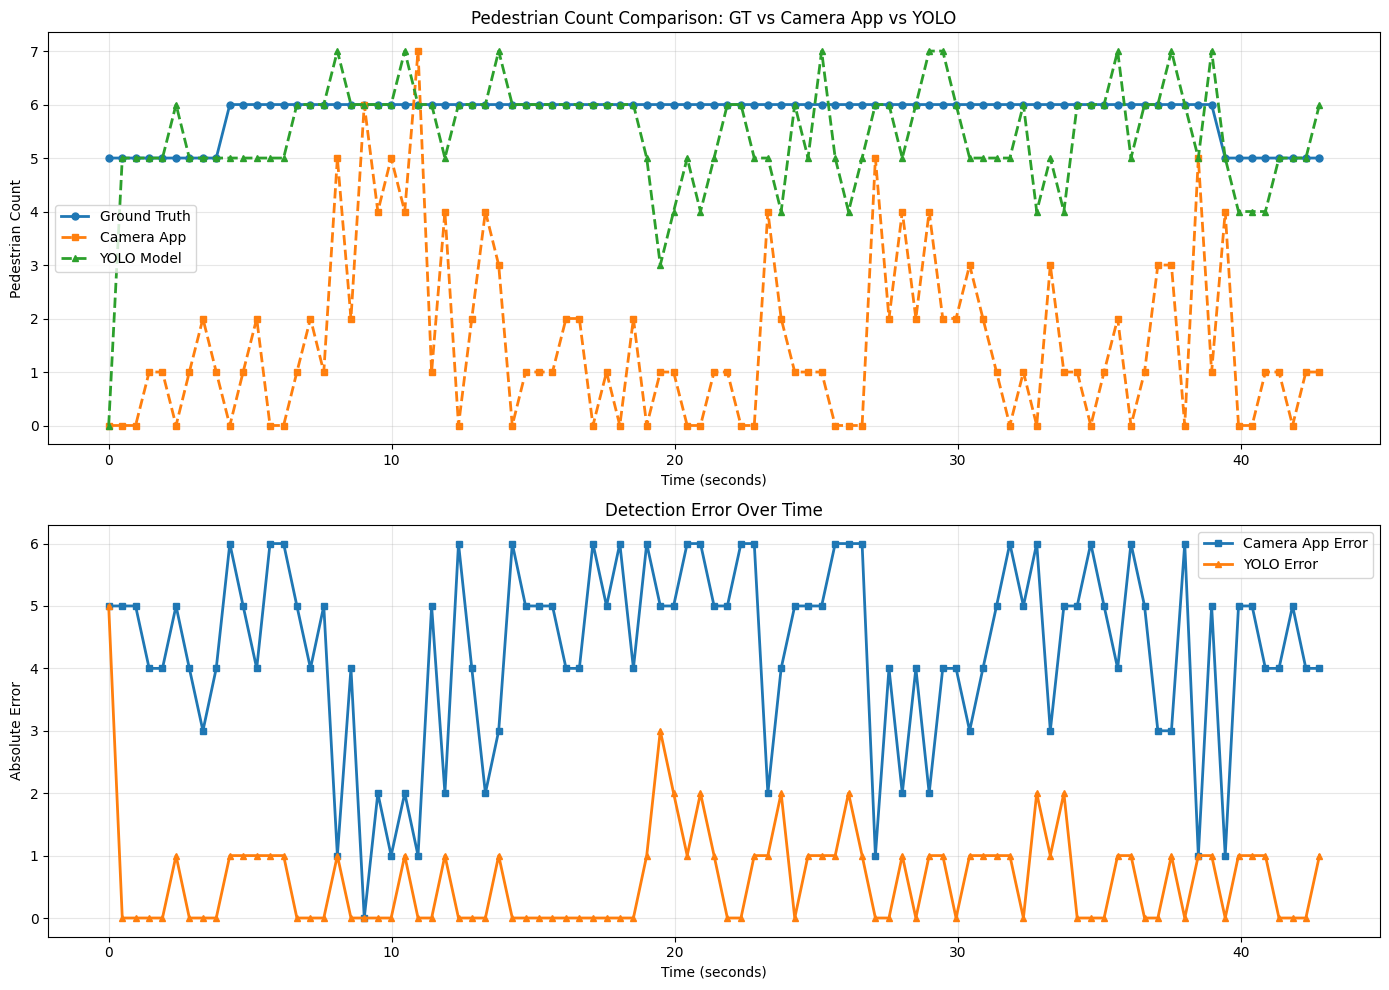

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

sample = df_comparison.iloc[::5]  # Every 5th frame for clarity

ax = axes[0]
ax.plot(sample['timestamp'], sample['ground_truth'], 'o-', label='Ground Truth', linewidth=2, markersize=5)
ax.plot(sample['timestamp'], sample['camera_app'], 's--', label='Camera App', linewidth=2, markersize=5)
ax.plot(sample['timestamp'], sample['yolo_model'], '^--', label='YOLO Model', linewidth=2, markersize=5)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Pedestrian Count')
ax.set_title('Pedestrian Count Comparison: GT vs Camera App vs YOLO')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(sample['timestamp'], sample['error_camera'], 's-', label='Camera App Error', linewidth=2, markersize=5)
ax.plot(sample['timestamp'], sample['error_yolo'], '^-', label='YOLO Error', linewidth=2, markersize=5)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Absolute Error')
ax.set_title('Detection Error Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
